# HGB 04 — Evaluation

Review standardized Peak-Risk metrics and key diagnostic visualizations.

In [1]:
# Import libraries
from pathlib import Path
import sys

In [2]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "hist_gradient_boosting_classifier.yaml"
CONFIG_PATH


WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/Codigo/ontario-electricity-peak-risk/configs/hist_gradient_boosting_classifier.yaml')

In [ ]:
# Import functions to run hist_gradient_boosting model
from src.ontario_peak_risk.models.peak_risk.hist_gradient_boosting.run_model import (
    run_hist_gradient_boosting_classifier,
)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay


## Additional Classification Diagnostics

The following analyses use the validation predictions already generated by the HistGradientBoostingClassifier.

The model is not retrained in this section.

The purpose is to evaluate:

- classification threshold behavior;
- Precision-Recall trade-offs;
- ROC performance;
- class imbalance;
- temporal stability;
- FSA-level performance;
- prediction probability distributions;
- Peak detection behavior over time.

In [4]:
# Load previously generated validation predictions.
# This avoids retraining the HistGradientBoostingClassifier.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

In [5]:
# Define config file
PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "modeling"
    / "peak_risk"
    / "hist_gradient_boosting"
    / "hist_gradient_boosting_validation_predictions.parquet"
)
PREDICTIONS_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/Codigo/ontario-electricity-peak-risk/outputs/modeling/peak_risk/hist_gradient_boosting/hist_gradient_boosting_validation_predictions.parquet')

In [6]:
# Get predictions
predictions = pd.read_parquet(
    PREDICTIONS_PATH
)

predictions["forecast_origin"] = pd.to_datetime(
    predictions["forecast_origin"]
)

print(
    f"Rows loaded: {len(predictions):,}"
)

print(
    f"Validation folds: "
    f"{sorted(predictions['fold'].unique())}"
)

print(
    f"FSAs: "
    f"{sorted(predictions['fsa'].unique())}"
)

display(
    predictions.head()
)

Rows loaded: 2,519,424
Validation folds: ['fold_2023', 'fold_2024']
FSAs: ['L4T', 'M5R', 'M5S', 'M6G', 'M9R', 'M9W']


,fold,fsa,forecast_origin,horizon,actual,predicted,probability
0,fold_2023,L4T,2023-01-01 00:00:00,1,0,0,0.000009
1,fold_2023,L4T,2023-01-01 01:00:00,1,0,0,0.000008
2,fold_2023,L4T,2023-01-01 02:00:00,1,0,0,0.000009
3,fold_2023,L4T,2023-01-01 03:00:00,1,0,0,0.000015
4,fold_2023,L4T,2023-01-01 04:00:00,1,0,0,0.000018


### Verify the current 0.50 threshold

In [7]:
# Evaluate the current classification threshold.
CURRENT_THRESHOLD = 0.50

predictions["predicted_050"] = (
    predictions["probability"]
    >= CURRENT_THRESHOLD
).astype("int8")

threshold_050_summary = pd.DataFrame(
    [
        {
            "threshold": CURRENT_THRESHOLD,
            "precision": precision_score(
                predictions["actual"],
                predictions["predicted_050"],
                zero_division=0,
            ),
            "recall": recall_score(
                predictions["actual"],
                predictions["predicted_050"],
                zero_division=0,
            ),
            "f1": f1_score(
                predictions["actual"],
                predictions["predicted_050"],
                zero_division=0,
            ),
            "pr_auc": average_precision_score(
                predictions["actual"],
                predictions["probability"],
            ),
            "roc_auc": roc_auc_score(
                predictions["actual"],
                predictions["probability"],
            ),
            "predicted_peak_rate_pct": (
                predictions["predicted_050"].mean()
                * 100
            ),
            "actual_peak_rate_pct": (
                predictions["actual"].mean()
                * 100
            ),
        }
    ]
)

display(
    threshold_050_summary
)

,threshold,precision,recall,f1,pr_auc,roc_auc,predicted_peak_rate_pct,actual_peak_rate_pct
0,0.5,0.822794,0.207605,0.331553,0.579909,0.908734,1.887971,7.482544


### Threshold sweep

In [8]:
# Evaluate different probability thresholds.
# This is a diagnostic analysis only.
# It does not automatically replace the official 0.50 threshold.

threshold_values = np.arange(
    0.05,
    0.96,
    0.05,
)

threshold_rows = []

for threshold in threshold_values:

    predicted = (
        predictions["probability"]
        >= threshold
    ).astype("int8")

    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                predictions["actual"],
                predicted,
                zero_division=0,
            ),
            "recall": recall_score(
                predictions["actual"],
                predicted,
                zero_division=0,
            ),
            "f1": f1_score(
                predictions["actual"],
                predicted,
                zero_division=0,
            ),
            "predicted_peak_rate_pct": (
                predicted.mean()
                * 100
            ),
        }
    )

threshold_analysis = pd.DataFrame(
    threshold_rows
)

display(
    threshold_analysis
)

,threshold,precision,recall,f1,predicted_peak_rate_pct
0,0.05,0.533891,0.578425,0.555267,8.106694
1,0.10,0.620436,0.486704,0.545493,5.869715
2,0.15,0.671434,0.428874,0.523418,4.779426
3,0.20,0.707585,0.384591,0.498328,4.066961
4,0.25,0.735706,0.347343,0.471894,3.532673
5,0.30,0.758914,0.314995,0.445204,3.105710
6,0.35,0.776918,0.285348,0.417395,2.748208
7,0.40,0.792938,0.258247,0.389606,2.436946
8,0.45,0.808746,0.232700,0.361412,2.152952
9,0.50,0.822794,0.207605,0.331553,1.887971


### Precision / Recall / F1 vs Threshold

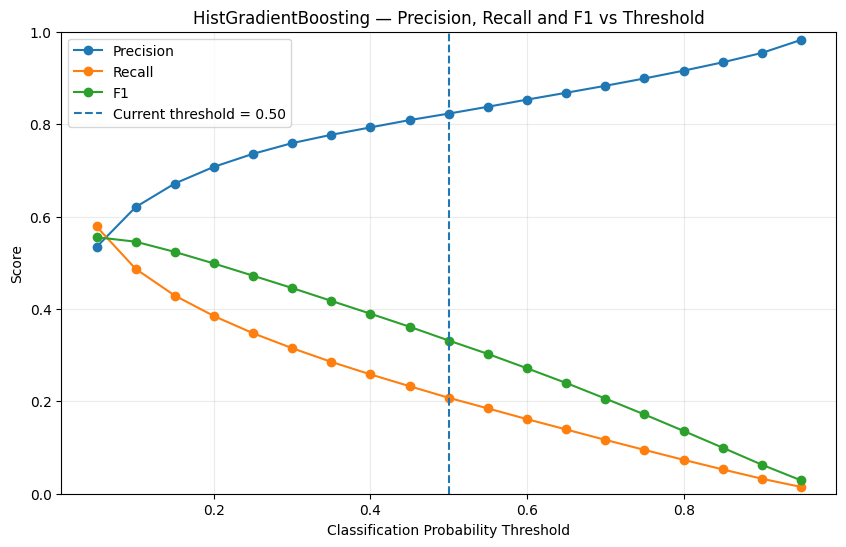

In [9]:
# Visualize the trade-off between Precision, Recall, and F1.
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["f1"],
    marker="o",
    label="F1",
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Current threshold = 0.50",
)

plt.xlabel(
    "Classification Probability Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "HistGradientBoosting — "
    "Precision, Recall and F1 vs Threshold"
)

plt.ylim(
    0,
    1,
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

### Find the threshold with highest F1

In [10]:
# Identify the threshold with the highest F1 score.
# This is diagnostic only and is not automatically adopted.

best_f1_row = (
    threshold_analysis
    .sort_values(
        "f1",
        ascending=False,
    )
    .iloc[0]
)

display(
    best_f1_row.to_frame(
        name="value"
    )
)

,value
threshold,0.050000
precision,0.533891
recall,0.578425
f1,0.555267
predicted_peak_rate_pct,8.106694


In [11]:
# Identify the threshold with the highest F1 score.
# This is diagnostic only and is not automatically adopted.

best_f1_row = (
    threshold_analysis
    .sort_values(
        "f1",
        ascending=False,
    )
    .iloc[0]
)

display(
    best_f1_row.to_frame(
        name="value"
    )
)

,value
threshold,0.050000
precision,0.533891
recall,0.578425
f1,0.555267
predicted_peak_rate_pct,8.106694


### Threshold analysis by fold

In [12]:
# Evaluate threshold behavior separately by validation fold.
fold_threshold_rows = []

for fold, fold_data in predictions.groupby(
    "fold"
):

    for threshold in threshold_values:

        predicted = (
            fold_data["probability"]
            >= threshold
        ).astype("int8")

        fold_threshold_rows.append(
            {
                "fold": fold,
                "threshold": threshold,
                "precision": precision_score(
                    fold_data["actual"],
                    predicted,
                    zero_division=0,
                ),
                "recall": recall_score(
                    fold_data["actual"],
                    predicted,
                    zero_division=0,
                ),
                "f1": f1_score(
                    fold_data["actual"],
                    predicted,
                    zero_division=0,
                ),
            }
        )

fold_threshold_analysis = pd.DataFrame(
    fold_threshold_rows
)

display(
    fold_threshold_analysis.head()
)

,fold,threshold,precision,recall,f1
0,fold_2023,0.05,0.682214,0.456804,0.547205
1,fold_2023,0.10,0.759349,0.362844,0.491048
2,fold_2023,0.15,0.800797,0.311655,0.448689
3,fold_2023,0.20,0.827769,0.275531,0.413443
4,fold_2023,0.25,0.848489,0.245946,0.381352


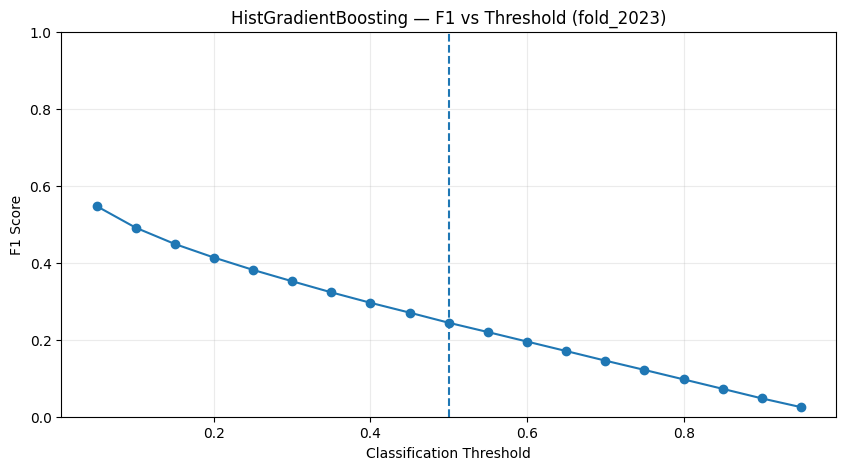

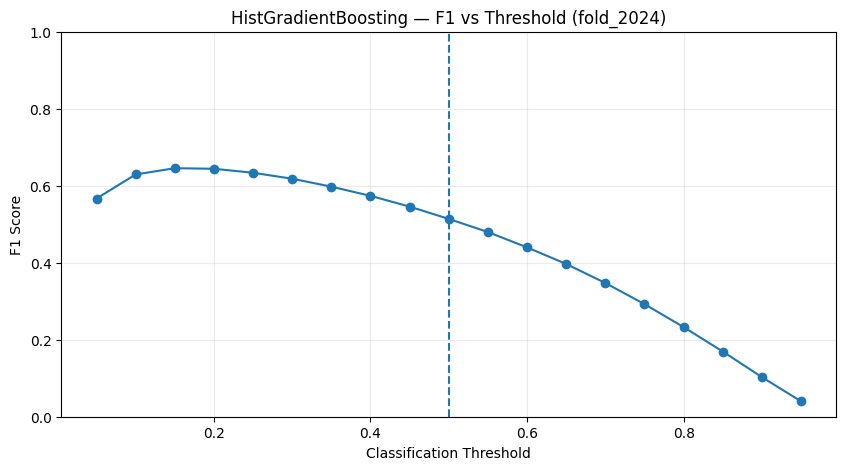

In [13]:
# Plot F1 by threshold for each validation fold.
for fold, group in fold_threshold_analysis.groupby(
    "fold"
):

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        group["threshold"],
        group["f1"],
        marker="o",
    )

    plt.axvline(
        0.50,
        linestyle="--",
    )

    plt.xlabel(
        "Classification Threshold"
    )

    plt.ylabel(
        "F1 Score"
    )

    plt.title(
        f"HistGradientBoosting — "
        f"F1 vs Threshold ({fold})"
    )

    plt.ylim(
        0,
        1,
    )

    plt.grid(
        alpha=0.25
    )

    plt.show()

### Precision-Recall Curve

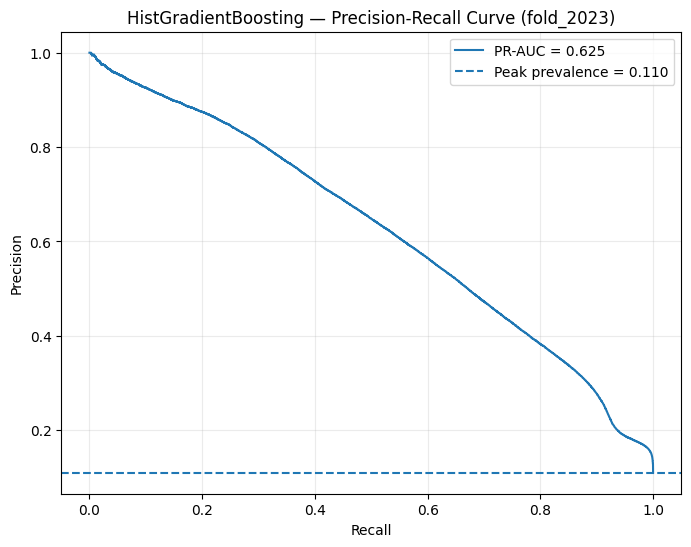

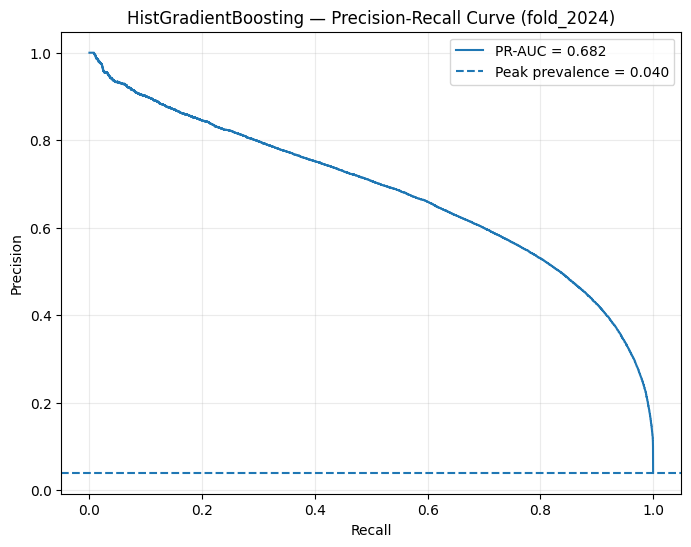

In [14]:
# Plot the Precision-Recall curve for each validation fold.
for fold, group in predictions.groupby(
    "fold"
):

    precision, recall, _ = (
        precision_recall_curve(
            group["actual"],
            group["probability"],
        )
    )

    pr_auc = (
        average_precision_score(
            group["actual"],
            group["probability"],
        )
    )

    baseline_rate = (
        group["actual"].mean()
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"PR-AUC = "
            f"{pr_auc:.3f}"
        ),
    )

    plt.axhline(
        baseline_rate,
        linestyle="--",
        label=(
            f"Peak prevalence = "
            f"{baseline_rate:.3f}"
        ),
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        f"HistGradientBoosting — "
        f"Precision-Recall Curve ({fold})"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.show()

### ROC Curve

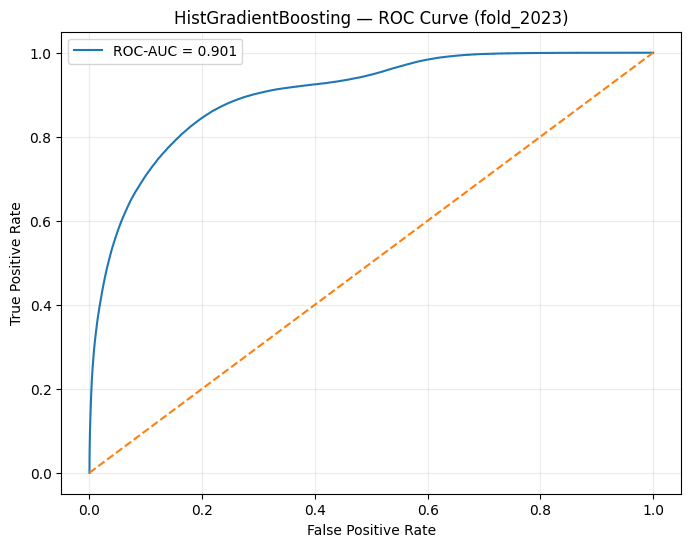

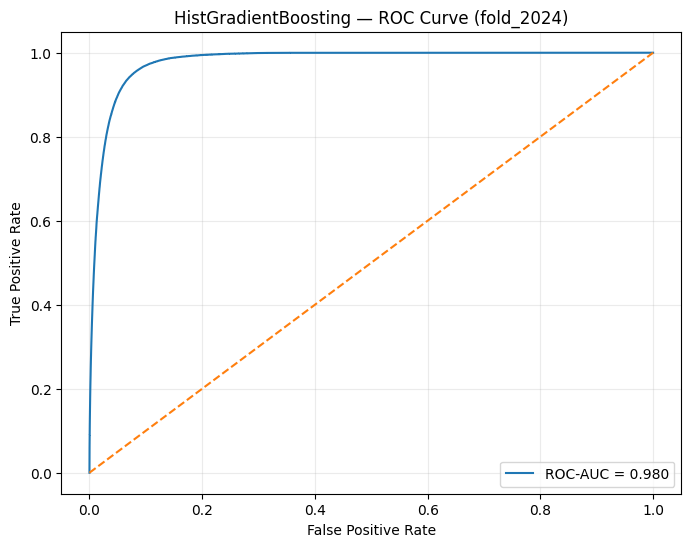

In [15]:
# Plot ROC curves by validation fold.

for fold, group in predictions.groupby(
    "fold"
):

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            group["actual"],
            group["probability"],
        )
    )

    roc_auc = roc_auc_score(
        group["actual"],
        group["probability"],
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"ROC-AUC = "
            f"{roc_auc:.3f}"
        ),
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        f"HistGradientBoosting — "
        f"ROC Curve ({fold})"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.show()

### Global confusion matrix at 0.50

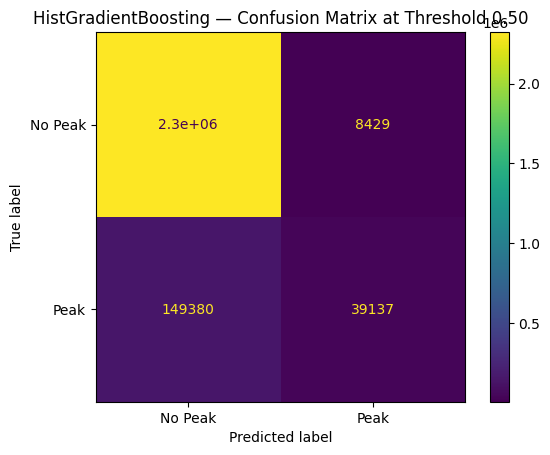

In [16]:
# Global confusion matrix using the official 0.50 threshold.

matrix_050 = confusion_matrix(
    predictions["actual"],
    predictions["predicted_050"],
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix_050,
    display_labels=[
        "No Peak",
        "Peak",
    ],
)

display_matrix.plot()

plt.title(
    "HistGradientBoosting — "
    "Confusion Matrix at Threshold 0.50"
)

plt.show()

### Confusion matrix by fold

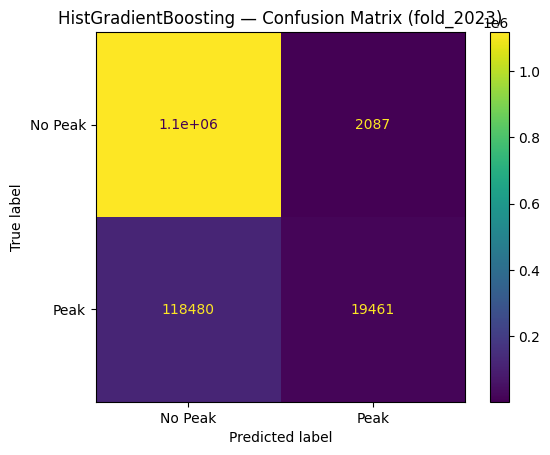

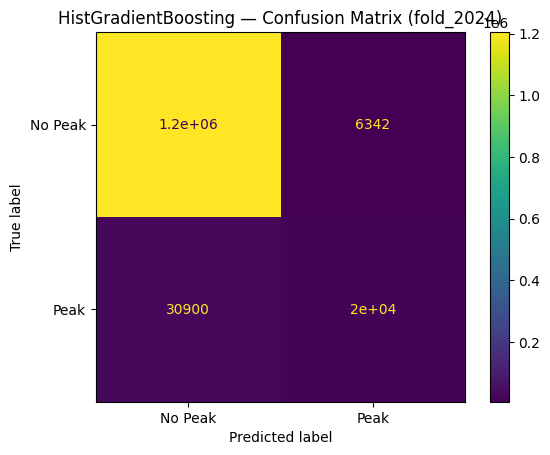

In [17]:
# Confusion matrix separately for every validation fold.

for fold, group in predictions.groupby(
    "fold"
):

    predicted = (
        group["probability"]
        >= 0.50
    ).astype("int8")

    matrix = confusion_matrix(
        group["actual"],
        predicted,
    )

    display_matrix = (
        ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=[
                "No Peak",
                "Peak",
            ],
        )
    )

    display_matrix.plot()

    plt.title(
        f"HistGradientBoosting — "
        f"Confusion Matrix ({fold})"
    )

    plt.show()

### Class balance by fold

In [18]:
# Calculate class balance by validation fold.
class_balance_fold = (
    predictions
    .groupby(
        [
            "fold",
            "actual",
        ],
        observed=True,
    )
    .size()
    .reset_index(
        name="count"
    )
)

class_balance_fold["class"] = (
    class_balance_fold[
        "actual"
    ]
    .map(
        {
            0: "No Peak",
            1: "Peak",
        }
    )
)

class_balance_fold["percentage"] = (
    class_balance_fold["count"]
    / class_balance_fold.groupby(
        "fold"
    )["count"].transform("sum")
    * 100
)

display(
    class_balance_fold
)

,fold,actual,count,class,percentage
0,fold_2023,0,1120043,No Peak,89.034757
1,fold_2023,1,137941,Peak,10.965243
2,fold_2024,0,1210864,No Peak,95.990614
3,fold_2024,1,50576,Peak,4.009386


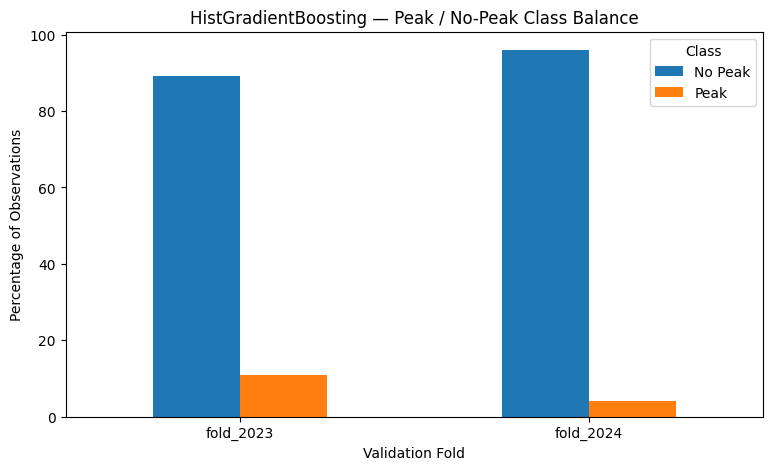

In [19]:
# Plot class distribution by validation fold.
class_balance_pivot = (
    class_balance_fold
    .pivot(
        index="fold",
        columns="class",
        values="percentage",
    )
)

class_balance_pivot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.xlabel(
    "Validation Fold"
)

plt.ylabel(
    "Percentage of Observations"
)

plt.title(
    "HistGradientBoosting — "
    "Peak / No-Peak Class Balance"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Class"
)

plt.show()

### Peak Rate by FSA and fold

In [20]:
# Calculate Peak prevalence by FSA and validation fold.
fsa_peak_rate = (
    predictions
    .groupby(
        [
            "fold",
            "fsa",
        ],
        observed=True,
    )["actual"]
    .mean()
    .mul(100)
    .reset_index(
        name="peak_rate_pct"
    )
)

display(
    fsa_peak_rate
)

,fold,fsa,peak_rate_pct
0,fold_2023,L4T,1.900183
1,fold_2023,M5R,1.968864
2,fold_2023,M5S,1.579670
3,fold_2023,M6G,5.574634
4,fold_2023,M9R,3.363954
5,fold_2023,M9W,51.404151
6,fold_2024,L4T,2.796804
7,fold_2024,M5R,1.678082
8,fold_2024,M5S,1.358447
9,fold_2024,M6G,3.641553


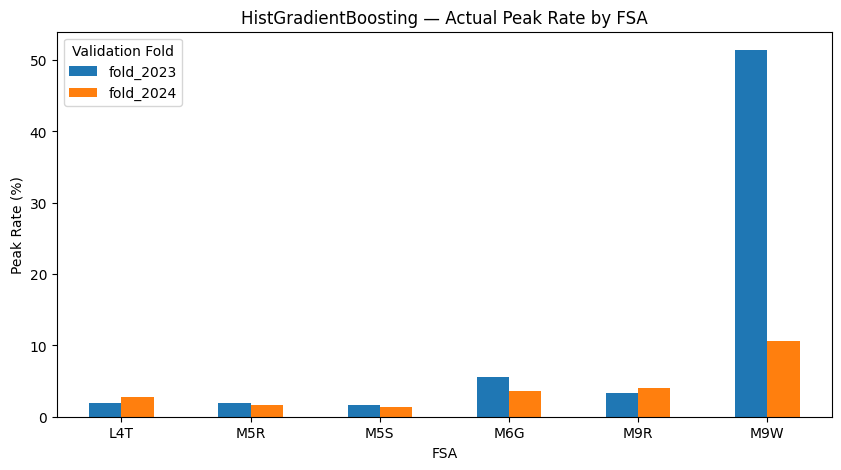

In [21]:
# Plot Peak rate by FSA.
pivot_peak_rate = (
    fsa_peak_rate
    .pivot(
        index="fsa",
        columns="fold",
        values="peak_rate_pct",
    )
)

pivot_peak_rate.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.xlabel(
    "FSA"
)

plt.ylabel(
    "Peak Rate (%)"
)

plt.title(
    "HistGradientBoosting — "
    "Actual Peak Rate by FSA"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Validation Fold"
)

plt.show()

### Probability distribution: Peak vs No Peak

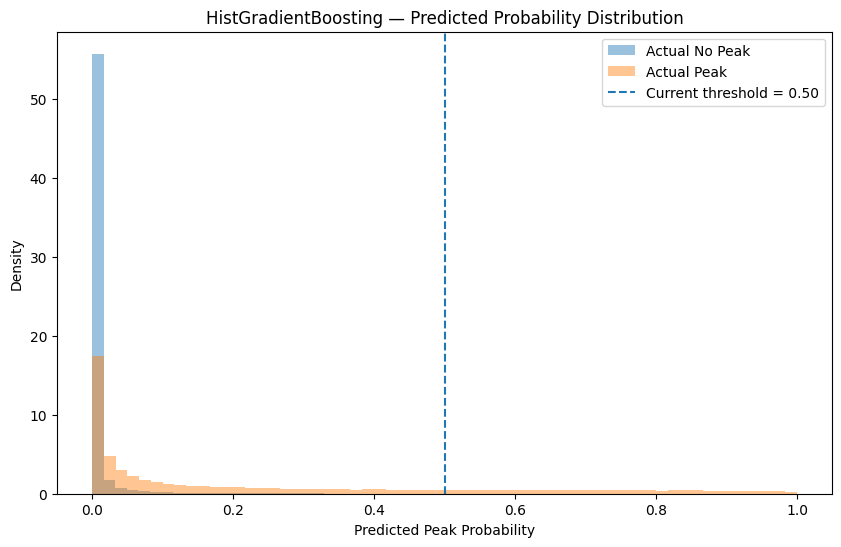

In [22]:
# Compare predicted probability distributions for actual Peak and No-Peak observations.
no_peak_probabilities = (
    predictions.loc[
        predictions["actual"] == 0,
        "probability",
    ]
)

peak_probabilities = (
    predictions.loc[
        predictions["actual"] == 1,
        "probability",
    ]
)

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    no_peak_probabilities,
    bins=60,
    density=True,
    alpha=0.45,
    label="Actual No Peak",
)

plt.hist(
    peak_probabilities,
    bins=60,
    density=True,
    alpha=0.45,
    label="Actual Peak",
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Current threshold = 0.50",
)

plt.xlabel(
    "Predicted Peak Probability"
)

plt.ylabel(
    "Density"
)

plt.title(
    "HistGradientBoosting — "
    "Predicted Probability Distribution"
)

plt.legend()

plt.show()

### Probability residual

- probability residual = actual - predicted probability

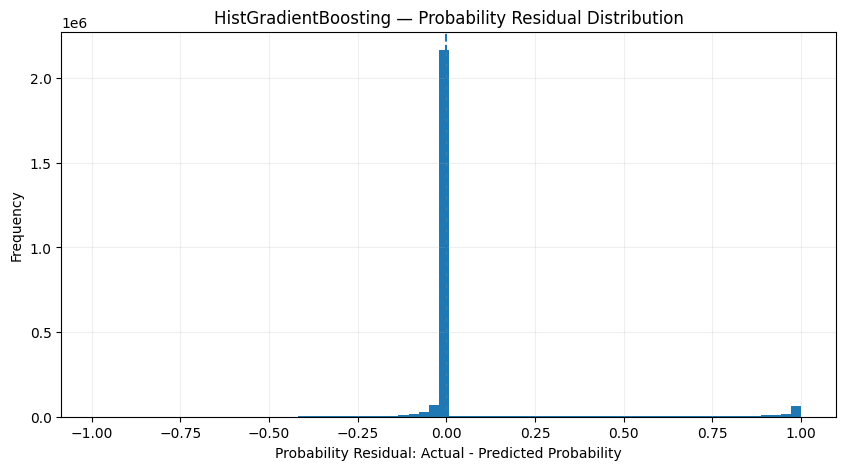

In [23]:
# Calculate probability residuals.
# This is a classification diagnostic, not a regression residual.
predictions["probability_residual"] = (
    predictions["actual"]
    - predictions["probability"]
)

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    predictions["probability_residual"],
    bins=70,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel(
    "Probability Residual: Actual - Predicted Probability"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "HistGradientBoosting — "
    "Probability Residual Distribution"
)

plt.grid(
    alpha=0.2
)

plt.show()

### Probability residual vs predicted probability

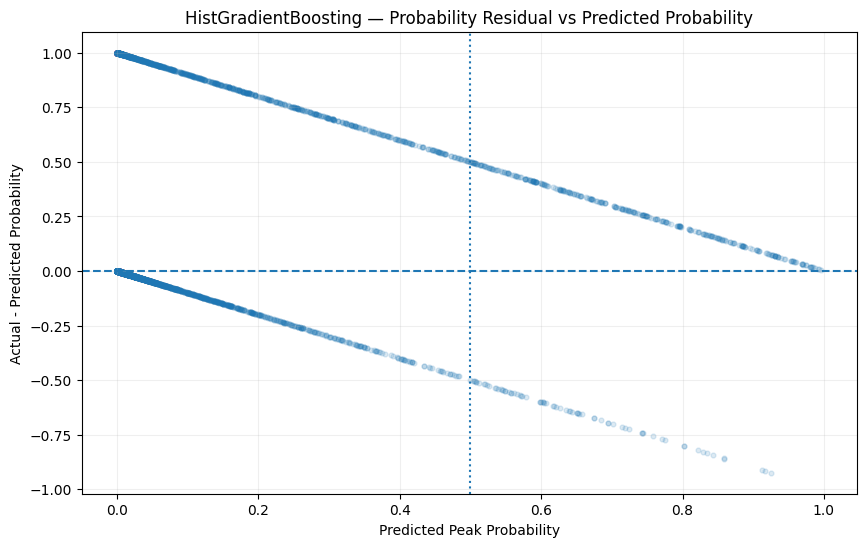

In [24]:
# Visualize probability residuals against model confidence.
sample = predictions.sample(
    n=min(
        20000,
        len(predictions),
    ),
    random_state=42,
)

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    sample["probability"],
    sample["probability_residual"],
    alpha=0.15,
    s=12,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.axvline(
    0.50,
    linestyle=":",
)

plt.xlabel(
    "Predicted Peak Probability"
)

plt.ylabel(
    "Actual - Predicted Probability"
)

plt.title(
    "HistGradientBoosting — "
    "Probability Residual vs Predicted Probability"
)

plt.grid(
    alpha=0.2
)

plt.show()

### PR-AUC and Recall by month

In [25]:
# Add temporal variables for monthly diagnostics.
predictions["month"] = (
    predictions[
        "forecast_origin"
    ]
    .dt.to_period("M")
    .astype(str)
)

In [26]:
# Calculate monthly classification performance.
monthly_rows = []

for (
    fold,
    month,
), group in predictions.groupby(
    [
        "fold",
        "month",
    ],
    observed=True,
):

    predicted = (
        group["probability"]
        >= 0.50
    ).astype("int8")

    monthly_rows.append(
        {
            "fold": fold,
            "month": month,
            "observations": len(group),
            "actual_peak_rate_pct": (
                group["actual"].mean()
                * 100
            ),
            "precision": precision_score(
                group["actual"],
                predicted,
                zero_division=0,
            ),
            "recall": recall_score(
                group["actual"],
                predicted,
                zero_division=0,
            ),
            "f1": f1_score(
                group["actual"],
                predicted,
                zero_division=0,
            ),
            "pr_auc": (
                average_precision_score(
                    group["actual"],
                    group["probability"],
                )
                if group["actual"].nunique() > 1
                else np.nan
            ),
        }
    )

monthly_metrics = pd.DataFrame(
    monthly_rows
)

display(
    monthly_metrics
)

,fold,month,observations,actual_peak_rate_pct,precision,recall,f1,pr_auc
0,fold_2023,2023-01,107136,9.340464,0.966972,0.190167,0.317829,0.715073
1,fold_2023,2023-02,96768,11.170015,0.956035,0.110649,0.198342,0.689964
2,fold_2023,2023-03,107136,17.474052,0.860037,0.197265,0.320921,0.645947
3,fold_2023,2023-04,103680,11.009838,1.000000,0.002628,0.005242,0.747011
4,fold_2023,2023-05,107136,11.741151,0.833537,0.108276,0.191656,0.688444
5,fold_2023,2023-06,103680,2.681327,0.764706,0.009353,0.018479,0.273378
6,fold_2023,2023-07,107136,7.707027,0.582822,0.057527,0.104718,0.383113
7,fold_2023,2023-08,107136,2.545363,0.306306,0.012468,0.023961,0.217152
8,fold_2023,2023-09,103680,19.785880,0.940000,0.201618,0.332022,0.765190
9,fold_2023,2023-10,107136,12.914427,1.000000,0.011492,0.022722,0.741056


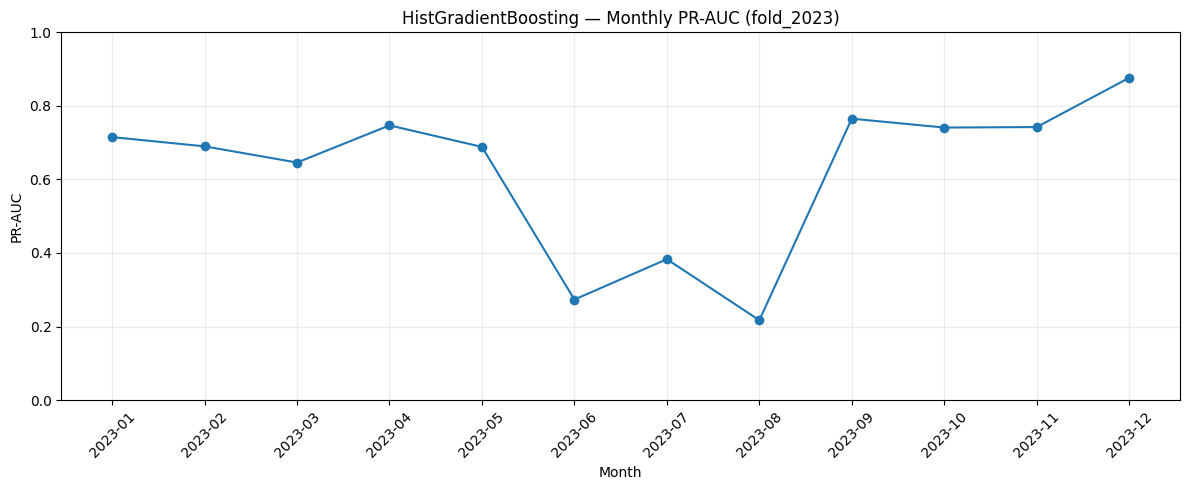

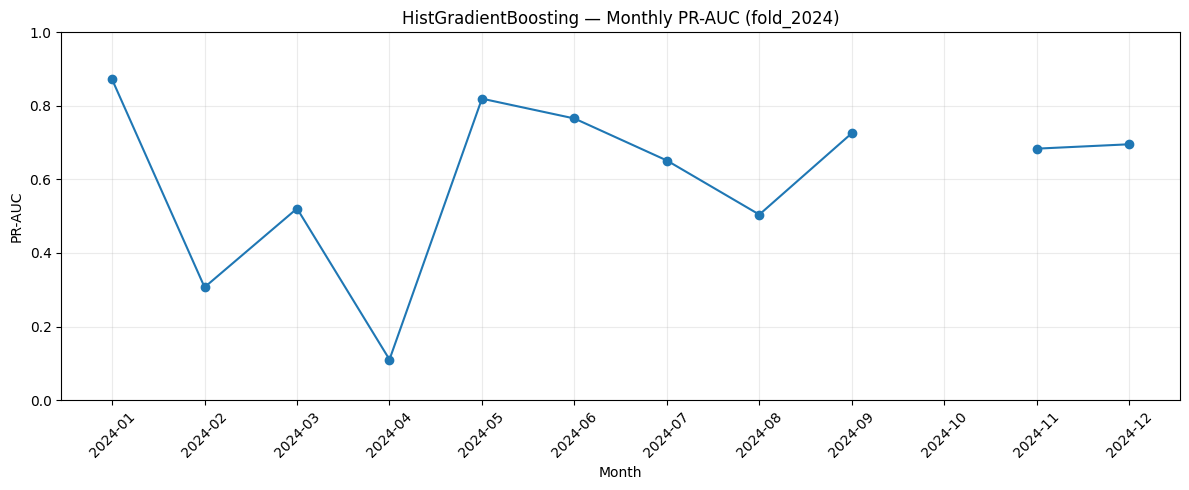

In [27]:
# Plot monthly PR-AUC.
for fold, group in monthly_metrics.groupby(
    "fold"
):

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        group["month"],
        group["pr_auc"],
        marker="o",
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "PR-AUC"
    )

    plt.title(
        f"HistGradientBoosting — "
        f"Monthly PR-AUC ({fold})"
    )

    plt.ylim(
        0,
        1,
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()

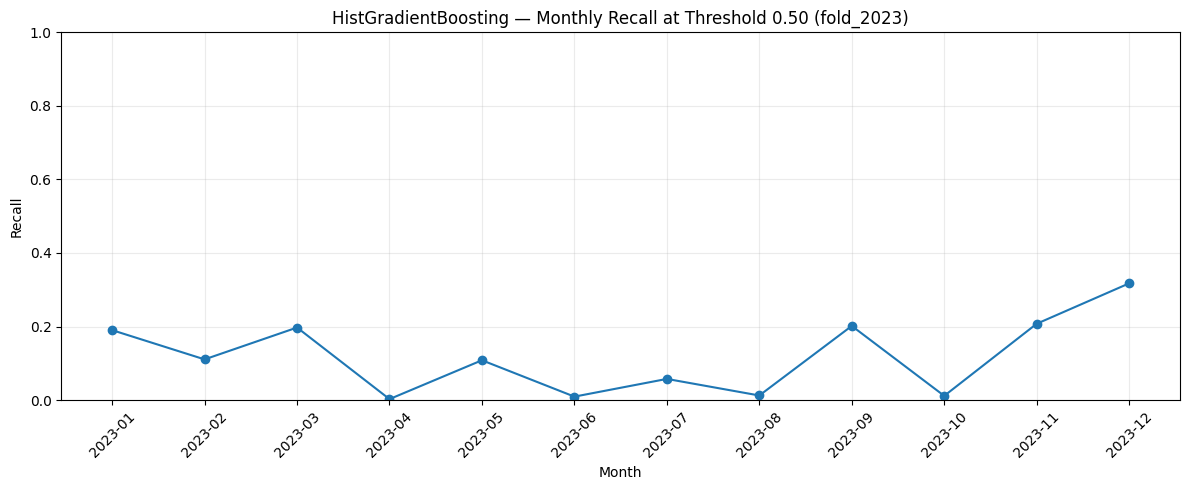

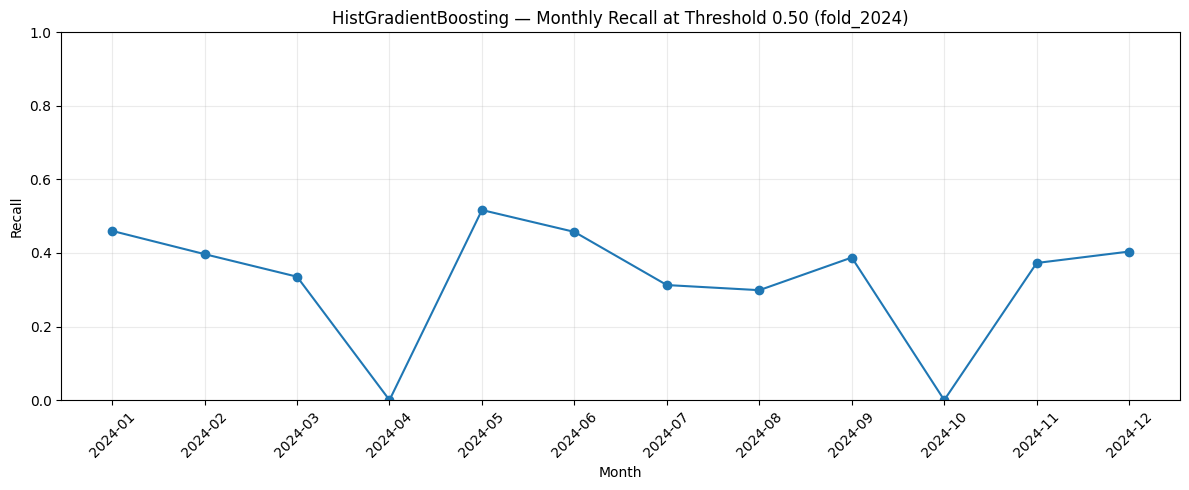

In [28]:
# Plot monthly Recall at threshold 0.50.
for fold, group in monthly_metrics.groupby(
    "fold"
):

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        group["month"],
        group["recall"],
        marker="o",
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Recall"
    )

    plt.title(
        f"HistGradientBoosting — "
        f"Monthly Recall at Threshold 0.50 ({fold})"
    )

    plt.ylim(
        0,
        1,
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()

### Error types TP / FP / FN / TN

In [29]:
# Classify every prediction by error type at the current 0.50 threshold.
conditions = [
    (
        (predictions["actual"] == 1)
        & (predictions["predicted_050"] == 1)
    ),
    (
        (predictions["actual"] == 0)
        & (predictions["predicted_050"] == 1)
    ),
    (
        (predictions["actual"] == 1)
        & (predictions["predicted_050"] == 0)
    ),
    (
        (predictions["actual"] == 0)
        & (predictions["predicted_050"] == 0)
    ),
]

labels = [
    "True Positive",
    "False Positive",
    "False Negative",
    "True Negative",
]

predictions["classification_result"] = (
    np.select(
        conditions,
        labels,
        default="Unknown",
    )
)

classification_summary = (
    predictions[
        "classification_result"
    ]
    .value_counts()
    .rename_axis(
        "classification_result"
    )
    .reset_index(
        name="count"
    )
)

classification_summary[
    "percentage"
] = (
    classification_summary["count"]
    / len(predictions)
    * 100
)

display(
    classification_summary
)

,classification_result,count,percentage
0,True Negative,2322478,92.182896
1,False Negative,149380,5.929133
2,True Positive,39137,1.553411
3,False Positive,8429,0.334561


### False Negative Rate by FSA

In [30]:
# Analyze missed Peaks by FSA.
peak_observations = predictions[
    predictions["actual"] == 1
].copy()

missed_peak_by_fsa = (
    peak_observations
    .groupby(
        [
            "fold",
            "fsa",
        ],
        observed=True,
    )
    .agg(
        actual_peaks=(
            "actual",
            "size",
        ),
        missed_peaks=(
            "classification_result",
            lambda values: (
                values
                == "False Negative"
            ).sum(),
        ),
    )
    .reset_index()
)

missed_peak_by_fsa[
    "missed_peak_rate_pct"
] = (
    missed_peak_by_fsa[
        "missed_peaks"
    ]
    / missed_peak_by_fsa[
        "actual_peaks"
    ]
    * 100
)

display(
    missed_peak_by_fsa
)

,fold,fsa,actual_peaks,missed_peaks,missed_peak_rate_pct
0,fold_2023,L4T,3984,2821,70.808233
1,fold_2023,M5R,4128,2974,72.044574
2,fold_2023,M5S,3312,1834,55.374396
3,fold_2023,M6G,11688,9743,83.359001
4,fold_2023,M9R,7053,5595,79.327946
5,fold_2023,M9W,107776,95513,88.621771
6,fold_2024,L4T,5880,3477,59.132653
7,fold_2024,M5R,3528,2294,65.022676
8,fold_2024,M5S,2856,1929,67.542017
9,fold_2024,M6G,7656,3836,50.104493


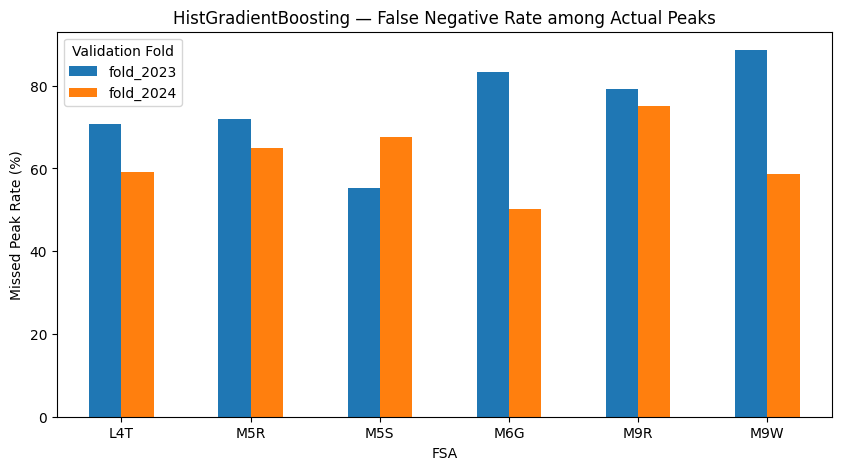

In [31]:
# Plot missed Peak rate by FSA.
missed_pivot = (
    missed_peak_by_fsa
    .pivot(
        index="fsa",
        columns="fold",
        values="missed_peak_rate_pct",
    )
)

missed_pivot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.xlabel(
    "FSA"
)

plt.ylabel(
    "Missed Peak Rate (%)"
)

plt.title(
    "HistGradientBoosting — "
    "False Negative Rate among Actual Peaks"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Validation Fold"
)

plt.show()

### Peak detection timeline

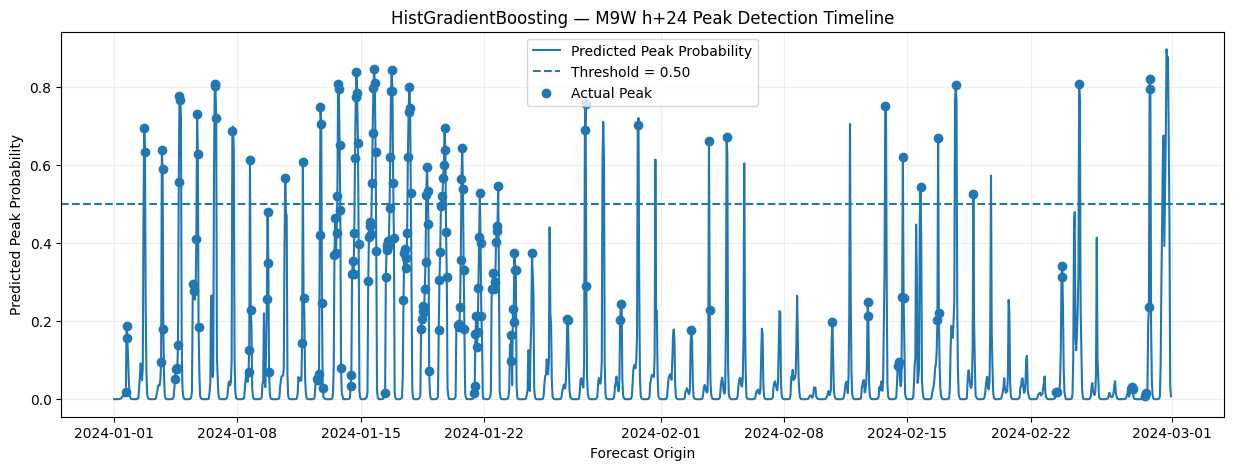

In [32]:
# Create a representative Peak detection timeline.
# One horizon is selected to avoid mixing overlapping forecasts.
timeline = (
    predictions[
        (predictions["fold"] == "fold_2024")
        & (predictions["fsa"] == "M9W")
        & (predictions["horizon"] == 24)
    ]
    .sort_values(
        "forecast_origin"
    )
    .copy()
)

# Use a representative 60-day window.
timeline = timeline.head(
    24 * 60
)

plt.figure(
    figsize=(15, 5)
)

plt.plot(
    timeline["forecast_origin"],
    timeline["probability"],
    label="Predicted Peak Probability",
)

plt.axhline(
    0.50,
    linestyle="--",
    label="Threshold = 0.50",
)

actual_peaks = timeline[
    timeline["actual"] == 1
]

plt.scatter(
    actual_peaks["forecast_origin"],
    actual_peaks["probability"],
    marker="o",
    label="Actual Peak",
)

plt.xlabel(
    "Forecast Origin"
)

plt.ylabel(
    "Predicted Peak Probability"
)

plt.title(
    "HistGradientBoosting — "
    "M9W h+24 Peak Detection Timeline"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

### True Positives vs Missed Peaks timeline

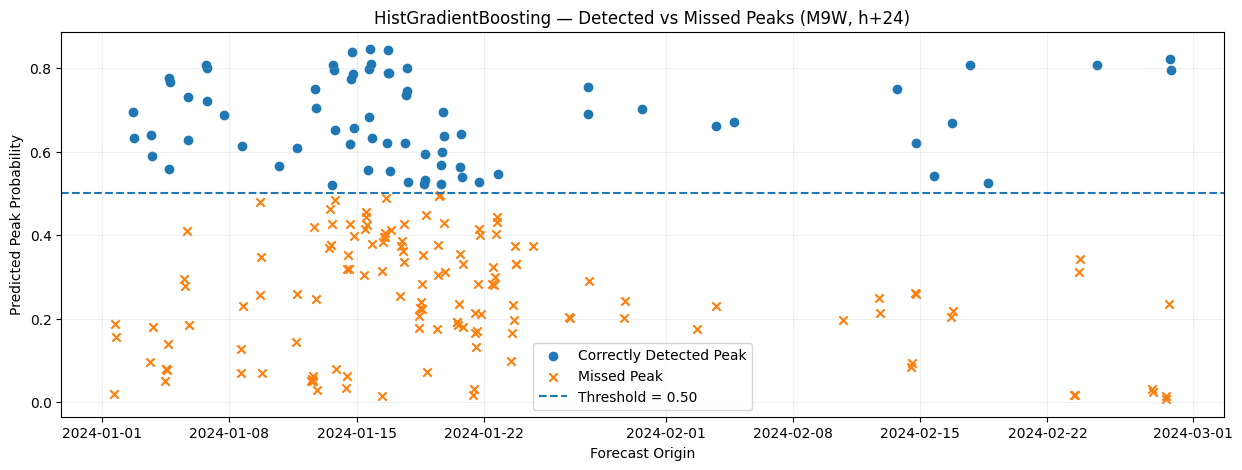

In [33]:
# Compare correctly detected and missed Peaks over time.
peak_timeline = timeline[
    timeline["actual"] == 1
].copy()

correctly_detected = peak_timeline[
    peak_timeline[
        "predicted_050"
    ] == 1
]

missed_peaks = peak_timeline[
    peak_timeline[
        "predicted_050"
    ] == 0
]

plt.figure(
    figsize=(15, 5)
)

plt.scatter(
    correctly_detected[
        "forecast_origin"
    ],
    correctly_detected[
        "probability"
    ],
    marker="o",
    label="Correctly Detected Peak",
)

plt.scatter(
    missed_peaks[
        "forecast_origin"
    ],
    missed_peaks[
        "probability"
    ],
    marker="x",
    label="Missed Peak",
)

plt.axhline(
    0.50,
    linestyle="--",
    label="Threshold = 0.50",
)

plt.xlabel(
    "Forecast Origin"
)

plt.ylabel(
    "Predicted Peak Probability"
)

plt.title(
    "HistGradientBoosting — "
    "Detected vs Missed Peaks (M9W, h+24)"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

### Actual consumption + Peak detection

In [34]:
# Load actual electricity demand to visualize Peak detection
# together with observed consumption.
from src.ontario_peak_risk.modeling.common import (
    load_feature_dataset,
    load_modeling_config,
)

FOUNDATION_CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "modeling_foundation.yaml"
)

FOUNDATION_CONFIG, _ = (
    load_modeling_config(
        FOUNDATION_CONFIG_PATH
    )
)

feature_dataset = (
    load_feature_dataset(
        FOUNDATION_CONFIG,
        PROJECT_ROOT,
    )
)

In [35]:
# Add the target timestamp and actual electricity demand.
timeline_consumption = timeline.copy()

timeline_consumption[
    "target_timestamp"
] = (
    timeline_consumption[
        "forecast_origin"
    ]
    + pd.to_timedelta(
        timeline_consumption[
            "horizon"
        ],
        unit="h",
    )
)

consumption_lookup = (
    feature_dataset
    .set_index(
        [
            "fsa",
            "timestamp",
        ]
    )[
        "total_consumption_kwh"
    ]
)

lookup_keys = (
    pd.MultiIndex.from_arrays(
        [
            timeline_consumption[
                "fsa"
            ],
            timeline_consumption[
                "target_timestamp"
            ],
        ],
        names=[
            "fsa",
            "timestamp",
        ],
    )
)

timeline_consumption[
    "consumption_kwh"
] = (
    consumption_lookup
    .reindex(
        lookup_keys
    )
    .to_numpy()
)

display(
    timeline_consumption.head()
)

,fold,fsa,forecast_origin,horizon,actual,predicted,probability,predicted_050,probability_residual,month,classification_result,target_timestamp,consumption_kwh
2510664,fold_2024,M9W,2024-01-01 00:00:00,24,0,0,0.000201,0,-0.000201,2024-01,True Negative,2024-01-02 00:00:00,12703.7
2510665,fold_2024,M9W,2024-01-01 01:00:00,24,0,0,0.000161,0,-0.000161,2024-01,True Negative,2024-01-02 01:00:00,11880.1
2510666,fold_2024,M9W,2024-01-01 02:00:00,24,0,0,0.000152,0,-0.000152,2024-01,True Negative,2024-01-02 02:00:00,11358.7
2510667,fold_2024,M9W,2024-01-01 03:00:00,24,0,0,0.000163,0,-0.000163,2024-01,True Negative,2024-01-02 03:00:00,11071.9
2510668,fold_2024,M9W,2024-01-01 04:00:00,24,0,0,0.000183,0,-0.000183,2024-01,True Negative,2024-01-02 04:00:00,11204.1


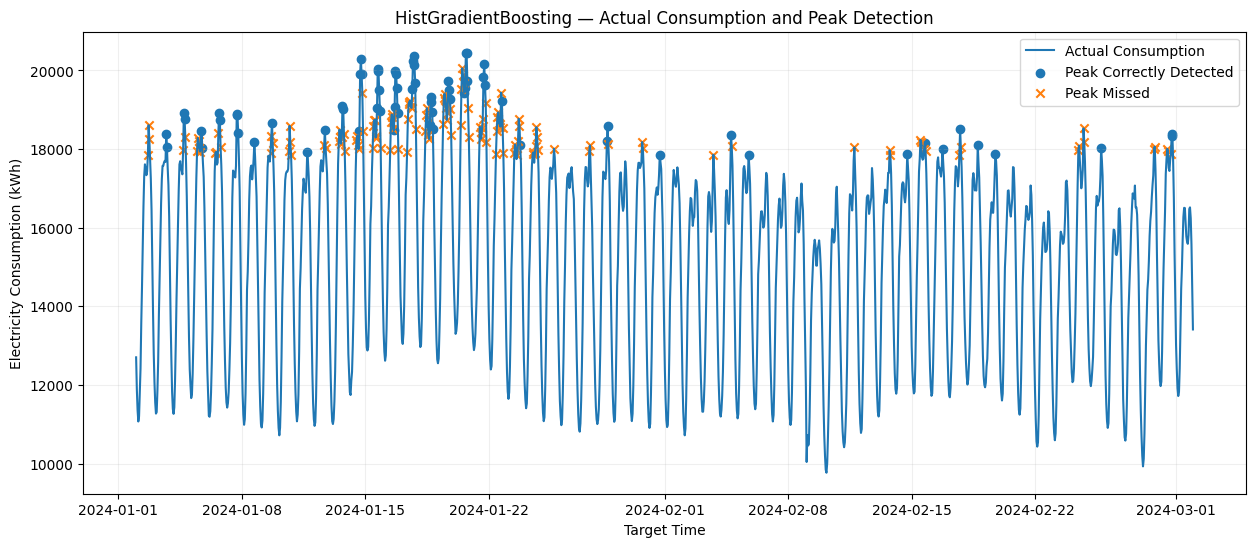

In [36]:
# Plot electricity demand and mark detected/missed Peak events.
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    timeline_consumption[
        "target_timestamp"
    ],
    timeline_consumption[
        "consumption_kwh"
    ],
    label="Actual Consumption",
)

true_positive = (
    timeline_consumption[
        (
            timeline_consumption[
                "actual"
            ] == 1
        )
        & (
            timeline_consumption[
                "predicted_050"
            ] == 1
        )
    ]
)

false_negative = (
    timeline_consumption[
        (
            timeline_consumption[
                "actual"
            ] == 1
        )
        & (
            timeline_consumption[
                "predicted_050"
            ] == 0
        )
    ]
)

plt.scatter(
    true_positive[
        "target_timestamp"
    ],
    true_positive[
        "consumption_kwh"
    ],
    marker="o",
    label="Peak Correctly Detected",
)

plt.scatter(
    false_negative[
        "target_timestamp"
    ],
    false_negative[
        "consumption_kwh"
    ],
    marker="x",
    label="Peak Missed",
)

plt.xlabel(
    "Target Time"
)

plt.ylabel(
    "Electricity Consumption (kWh)"
)

plt.title(
    "HistGradientBoosting — "
    "Actual Consumption and Peak Detection"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()